# Reddit dataset - basic metrics (cleaned data)

Same checks and charts as `basic_metrics_v3.ipynb`, but run on the output of `data_cleaning.ipynb` (`data/cleaned/`).

Dataset = the two parquet files in `data/cleaned/`. The raw files in `data/` are only used for before/after row counts (read from the footer).
Nothing loads full data — sizes from stat(), rows from the parquet footer, category counts streamed per row-group.

In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq

DATA = next(p for p in (Path.cwd() / "data", Path.cwd().parent / "data") if p.is_dir())
FILES = {"submissions": DATA / "cleaned" / "submissions_clean.parquet", "comments": DATA / "cleaned" / "comments_clean.parquet"}
RAW = {"submissions": DATA / "submissions_trump.parquet", "comments": DATA / "comments_trump.parquet"}
files = {k: pq.ParquetFile(p) for k, p in FILES.items()}
raw_md = {k: pq.ParquetFile(p).metadata for k, p in RAW.items()}

## size, rows, breakdown by type

In [2]:
overview = pd.DataFrame(
    {
        "size_MB": [FILES[k].stat().st_size / 1024**2 for k in files],
        "rows": [f.metadata.num_rows for f in files.values()],
        "rows_raw": [raw_md[k].num_rows for k in files],
        "columns": [f.metadata.num_columns for f in files.values()],
        "columns_raw": [raw_md[k].num_columns for k in files],
    },
    index=list(files),
)
overview["rows_%"] = 100 * overview["rows"] / overview["rows"].sum()
overview.loc["TOTAL"] = overview.sum()
overview["rows_removed_%"] = 100 * (1 - overview["rows"] / overview["rows_raw"])
overview.round(1)

,size_MB,rows,rows_raw,columns,columns_raw,rows_%,rows_removed_%
submissions,98.7,507206.0,513848.0,29.0,132.0,10.1,1.3
comments,2032.3,4499514.0,4601620.0,23.0,87.0,89.9,2.2
TOTAL,2131.0,5006720.0,5115468.0,52.0,219.0,100.0,2.1


RAM a plain `read_parquet` would need (measured on a sample, extrapolated by row count). Raw comments needed ~7.3 GB; the cleaned file needs about half, since 64 columns were dropped (even with the extra `body_clean` text).

In [3]:
def est_pandas_gb(name, batch=20_000, n_samples=24):
    f = files[name]
    if f.metadata.num_row_groups >= n_samples:
        # one batch from the start of every row group so different periods are sampled
        batches = (next(f.iter_batches(batch_size=batch, row_groups=[i])) for i in range(f.metadata.num_row_groups))
    else:
        # few row groups (submissions = 1) -> take every k-th batch across the file instead
        step = max(1, -(-f.metadata.num_rows // batch) // n_samples)
        batches = (b for i, b in enumerate(f.iter_batches(batch_size=batch)) if i % step == 0)
    sample = pd.concat(b.to_pandas() for b in batches)
    per_row = sample.memory_usage(deep=True).sum() / len(sample)
    return {"sample_rows": len(sample), "bytes_per_row": per_row,
            "est_pandas_GB": per_row * f.metadata.num_rows / 1024**3}


est = pd.DataFrame({k: est_pandas_gb(k) for k in files}).T
est.loc["TOTAL", "est_pandas_GB"] = est["est_pandas_GB"].sum()
est.round(2)

,sample_rows,bytes_per_row,est_pandas_GB
submissions,507206.0,553.65,0.26
comments,461593.0,888.13,3.72
TOTAL,NaN,NaN,3.98


## counts per category

Categorical columns present in both files: `subreddit`, `source_month` and (new after cleaning) `period`.
Counted row-group by row-group so the 2 GB comments file never lands in RAM at once.

In [4]:
def count_by(name, column):
    f = files[name]
    counts = Counter()
    for i in range(f.metadata.num_row_groups):
        counts.update(f.read_row_group(i, columns=[column])[column].to_pylist())
    return pd.Series(counts, name=name).sort_values(ascending=False)


by_month = pd.concat([count_by(k, "source_month") for k in files], axis=1).sort_index()
by_month.style.format("{:,}").background_gradient(cmap="Blues")

,submissions,comments
2017-01,"38,409","371,170"
2017-02,"37,615","314,228"
2017-03,"33,250","284,259"
2017-04,"25,344","199,126"
2017-05,"34,381","291,016"
2017-06,"26,371","258,619"
2018-01,"28,691","250,842"
2018-02,"22,940","192,220"
2018-03,"26,763","219,609"
2018-04,"23,876","211,721"


distinct subreddits: 6


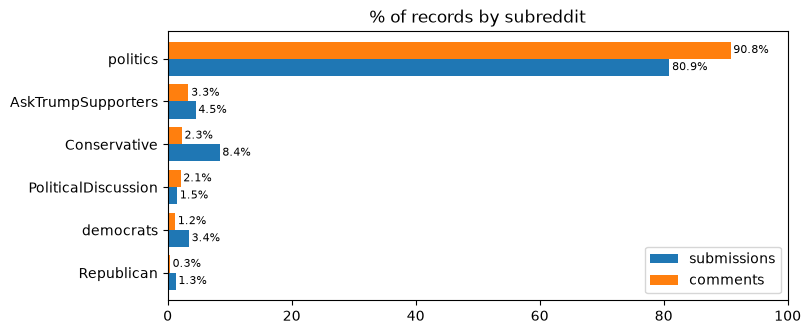

In [5]:
by_sub = pd.concat([count_by(k, "subreddit") for k in files], axis=1).fillna(0).astype(int)
print(f"distinct subreddits: {len(by_sub):,}")
share = 100 * by_sub / by_sub.sum()
ax = share.sort_values("comments").plot.barh(figsize=(8, 3.5), width=0.8, xlim=(0, 100), title="% of records by subreddit")
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=8)

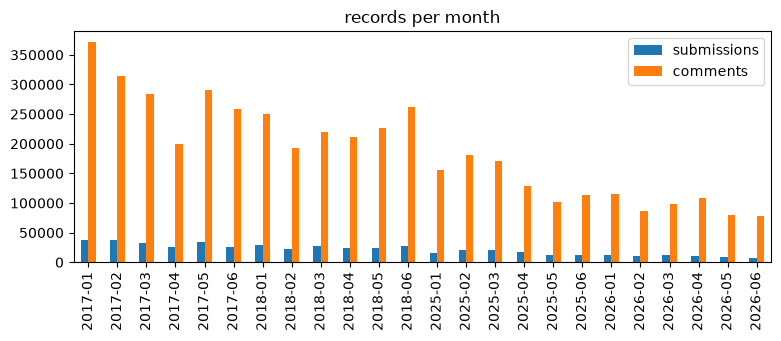

In [6]:
by_month.plot.bar(figsize=(9, 3), title="records per month");

,submissions,comments
T1_Y1,"195,370","1,718,418"
T1_Y2,"153,094","1,363,088"
T2_Y1,"97,218","850,092"
T2_Y2,"61,524","567,916"


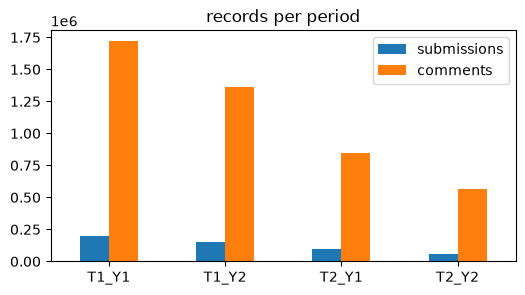

In [7]:
# period = first / second year of each Trump term (T1 = 2017-2018, T2 = 2025-2026)
by_period = pd.concat([count_by(k, "period") for k in files], axis=1).sort_index()
display(by_period.style.format("{:,}").background_gradient(cmap="Blues"))
by_period.plot.bar(figsize=(6, 3), rot=0, title="records per period");

## duplicates

Reddit `id` is unique per comment / per submission, so a repeated id = same record collected twice. Only the `id` column is read.

In [8]:
def dup_check(name):
    ids = files[name].read(columns=["id"])["id"]
    valid = len(ids) - ids.null_count
    return {"rows": len(ids), "null_ids": ids.null_count, "duplicate_rows": valid - pc.count_distinct(ids).as_py()}


pd.DataFrame({k: dup_check(k) for k in files}).T

,rows,null_ids,duplicate_rows
submissions,507206,0,0
comments,4499514,0,0


## head

First 3 rows, transposed (29 / 23 columns). Note: rows are sorted by time, so the first rows are all 2017-01.

In [9]:
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", 60):
    for k, f in files.items():
        print(k)
        display(next(f.iter_batches(batch_size=3)).to_pandas().T)

submissions


,0,1,2
id,5lch1i,5lci8r,5lciy3
created_utc,1483228990,1483229424,1483229651
source_month,2017-01,2017-01,2017-01
subreddit,politics,politics,politics
author,Gaybro1992,gazil9,[deleted]
author_flair_text,<NA>,<NA>,<NA>
title,Trump ditches press pool to play golf,"Putin won 2016, but Russia has its limits as a superpower​","This Photo of a Trump Billboard in Mumbai is Real, and s..."
selftext,,,
is_self,False,False,False
domain,cnn.com,washingtonpost.com,m.huffpost.com


comments


,0,1,2
id,dbumnwy,dbumos7,dbumotn
submission_id,5lbx9q,5lbdw1,5lbx9q
parent_id,t3_5lbx9q,t1_dbufh70,t1_dbule2l
created_utc,1483228808,1483228848,1483228850
source_month,2017-01,2017-01,2017-01
subreddit,politics,politics,politics
author,GaryRuppert,Kichigai,GaryRuppert
author_flair_text,America,Minnesota,America
body,Kind of a shame for Bill Clinton that he's determined to...,"Please, McCain has done more to try and unite the countr...",remember when Dems said Trump had no GOTV operation?
score,4,7,0


## missing values

Null counts straight from the parquet footer (no data read). NaN in the table = column not in that file.

In [10]:
def null_counts(name):
    f = files[name]
    md = f.metadata
    out = {}
    for j in range(md.num_columns):
        stats = [md.row_group(i).column(j).statistics for i in range(md.num_row_groups)]
        c = md.schema.column(j).name
        if all(s is not None and s.has_null_count for s in stats):
            out[c] = sum(s.null_count for s in stats)
        else:  # no footer stats (all-null columns) -> read it, cheap
            out[c] = f.read(columns=[c])[c].null_count
    s = pd.Series(out)
    return pd.DataFrame({"nulls": s, "null_%": (100 * s / md.num_rows).round(1)})


nulls = pd.concat({k: null_counts(k) for k in files}, axis=1)
all_null = {k: nulls.index[nulls[(k, "nulls")] == files[k].metadata.num_rows].tolist() for k in files}
for k, cols in all_null.items():
    print(f"{k}: {len(cols)} columns 100% null:", cols)
with pd.option_context("display.max_rows", None):
    display(nulls[(nulls.xs("null_%", axis=1, level=1) > 0).any(axis=1)].sort_values(("comments", "null_%")))

submissions: 0 columns 100% null: []
comments: 0 columns 100% null: []


submissions          comments       
                          nulls null_%      nulls null_%
is_submitter                NaN    NaN  1718418.0   38.2
author_flair_text      398510.0   78.6  3673295.0   81.6
stance                 490082.0   96.6  4354899.0   96.8
link_flair_text        272817.0   53.8        NaN    NaN
upvote_ratio           348464.0   68.7        NaN    NaN
removed_by_category    460911.0   90.9        NaN    NaN
distinguished          506803.0   99.9        NaN    NaN

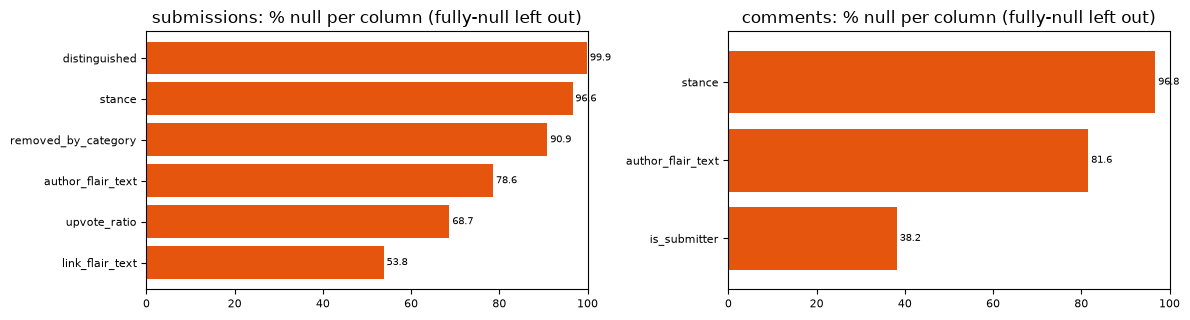

In [11]:
partial = {k: nulls[(k, "null_%")].drop(all_null[k]).dropna().loc[lambda s: s > 0].sort_values() for k in files}
fig, axes = plt.subplots(1, 2, figsize=(12, 0.3 * max(len(s) for s in partial.values()) + 1.5))
for ax, (k, s) in zip(axes, partial.items()):
    if s.empty:
        ax.set_title(f"{k}: no partially-null columns")
        continue
    s.plot.barh(ax=ax, width=0.8, xlim=(0, 100), color="#e6550d", fontsize=8,
                title=f"{k}: % null per column (fully-null left out)")
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=2, fontsize=7)
fig.tight_layout()

In [12]:
# nulls come in whole-month blocks (field missing from that period's dump) -> % null per month
# red = missing, white = present; rows sorted so columns with the same gap pattern sit together
def null_pct_by_month(name, cols):
    f = files[name]
    month = f.read(columns=["source_month"])["source_month"].to_pandas()
    df = pd.DataFrame({c: f.read(columns=[c])[c].is_null().to_pandas().groupby(month).mean() * 100 for c in cols}).T.round().astype(int)
    return df.sort_values(list(df.columns))


for k in files:
    cols = nulls.index[(nulls[(k, "nulls")] > 0) & (nulls[(k, "nulls")] < files[k].metadata.num_rows)]
    print(k)
    display(null_pct_by_month(k, cols).style.background_gradient(cmap="Reds", vmin=0, vmax=100, axis=None)
            .set_table_styles([{"selector": "td, th", "props": "font-size: 9px; padding: 1px 4px"}]))

submissions


source_month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
link_flair_text,58,64,64,61,64,57,72,73,70,73,72,75,37,38,38,40,39,39,8,7,7,6,6,6
author_flair_text,86,84,86,83,82,82,82,80,82,100,100,78,68,70,69,67,63,61,62,61,61,60,59,57
stance,96,95,99,97,97,97,98,97,98,100,100,97,95,94,95,95,96,96,95,95,94,95,95,95
upvote_ratio,100,100,100,100,100,100,100,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0
removed_by_category,100,100,100,100,100,100,100,100,100,100,100,100,64,62,66,68,73,73,72,76,77,77,80,83
distinguished,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100


comments


source_month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
author_flair_text,86,84,85,83,82,81,80,81,79,79,78,80,83,83,82,81,81,81,81,81,80,81,79,80
stance,96,95,97,97,97,97,97,98,98,98,96,96,98,97,97,97,98,99,97,97,96,97,96,97
is_submitter,100,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### pseudo-missing

Real strings that mean "no value" — footer null counts don't see them.
Expected after cleaning: `selftext` = `""` for link posts and for the removed/deleted posts (placeholders were replaced by `""`, see `is_removed`);
`[deleted]` authors are kept on purpose (flag `author_deleted`); `body` keeps the original text, `body_clean` is the one for NLP.

In [13]:
PSEUDO_VALUES = ["", "nan", "None", "NaN", "[deleted]", "[removed]"]


def pseudo_shares(name, column):
    # streamed per row group: body / body_clean are too big to read at once
    f = files[name]
    counts = Counter()
    for i in range(f.metadata.num_row_groups):
        col = f.read_row_group(i, columns=[column])[column]
        hits = col.filter(pc.is_in(col, value_set=pa.array(PSEUDO_VALUES, type=col.type)))
        counts.update({v["values"]: v["counts"] for v in pc.value_counts(hits).to_pylist()})
    return {v: 100 * n / f.metadata.num_rows for v, n in counts.items()}


pseudo = {(k, c): pseudo_shares(k, c)
          for k, cols in {"submissions": ["author", "title", "selftext", "text"], "comments": ["author", "body", "body_clean"]}.items()
          for c in cols}
print("% of rows")
(pd.DataFrame(pseudo).T.reindex(columns=PSEUDO_VALUES).fillna(0).rename(columns={"": "<empty>"})
 .style.format("{:.1f}").background_gradient(cmap="Oranges", vmin=0, axis=None))

% of rows


## cleaning flags per month

`quarantine` and `pinned` (the mixed float/string columns checked in v3) were dropped during cleaning.
Instead: the boolean flags of the cleaned tables, % True per month.

In [14]:
FLAGS = {
    "submissions": ["is_removed", "author_deleted", "is_mod_post", "submission_mentions_trump", "has_trump_comment", "is_self", "stickied"],
    "comments": ["author_deleted", "trump_only_in_quote", "is_top_level", "is_submitter", "edited", "stickied"],
}


def flag_pct_by_month(name, cols):
    t = files[name].read(columns=["source_month", *cols]).to_pandas()
    t[cols] = t[cols].astype("boolean")  # nullable: mean() skips missing values
    return 100 * t.groupby("source_month")[cols].mean().astype(float)


pd.concat({k: flag_pct_by_month(k, cols) for k, cols in FLAGS.items()}, axis=1).style.format("{:.1f}").background_gradient(cmap="Greens", axis=None)

## other low-cardinality columns

Full scan: every column with ≤5 distinct values.
Each bar = one column, split into False-like (`False`, `0`, `0.0`), True-like (`True`, `1`, `1.0`), other values and null.
!! = not stored as `bool` but holds only True/False-like values → should be cast to bool (expected: none left after cleaning).

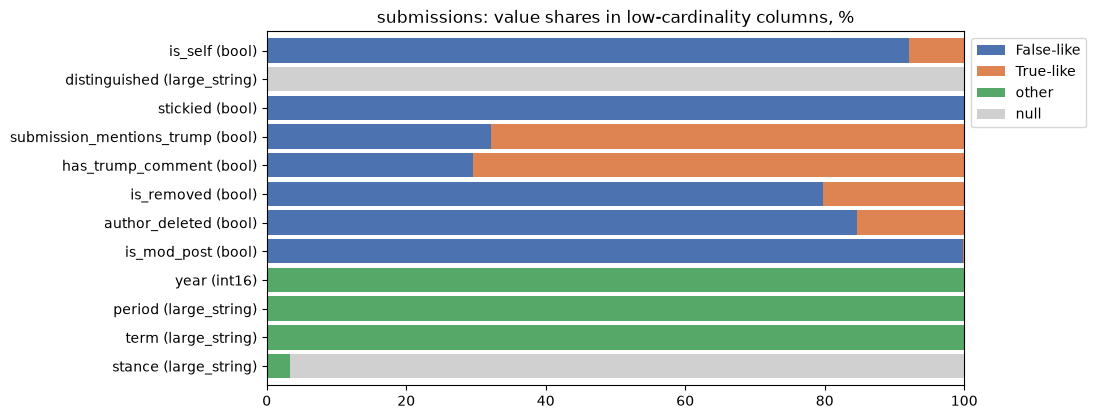

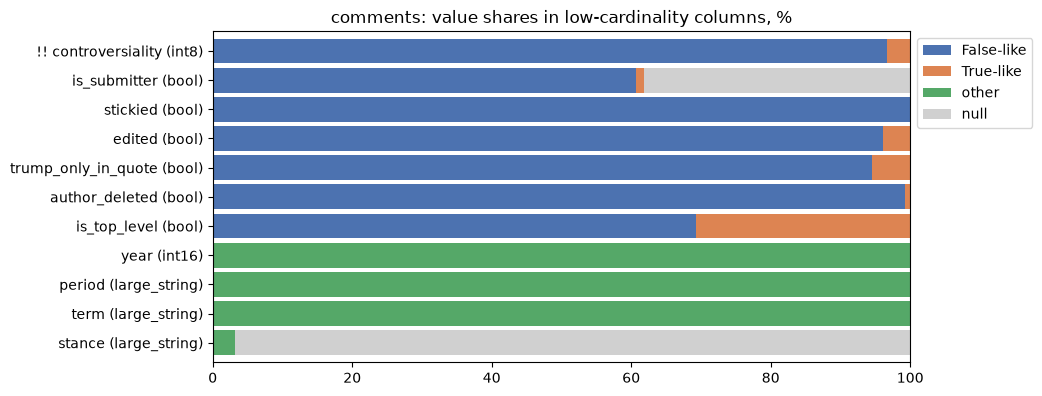

In [15]:
FALSE_LIKE, TRUE_LIKE = {"False", "false", "0", "0.0"}, {"True", "true", "1", "1.0"}
COLORS = {"False-like": "#4c72b0", "True-like": "#dd8452", "other": "#55a868", "null": "#d0d0d0"}


def kind(v):
    return "null" if v is None else "False-like" if str(v) in FALSE_LIKE else "True-like" if str(v) in TRUE_LIKE else "other"


def value_shares(name, max_mb=100, max_distinct=5):
    md = files[name].metadata
    rows = {}
    for j in range(md.num_columns):
        c = md.schema.column(j).name
        # skip heavy text columns (body, text, url) — never low-cardinality anyway
        if sum(md.row_group(i).column(j).total_uncompressed_size for i in range(md.num_row_groups)) > max_mb * 1024**2:
            continue
        col = files[name].read(columns=[c])[c]
        if pa.types.is_null(col.type) or pc.count_distinct(col).as_py() > max_distinct:
            continue
        vc = pc.value_counts(col).to_pylist()
        s = pd.Series([v["counts"] for v in vc], index=[kind(v["values"]) for v in vc]).groupby(level=0).sum()
        warn = "!! " if not pa.types.is_boolean(col.type) and set(s.index) - {"null"} and set(s.index) - {"null"} <= {"False-like", "True-like"} else ""
        rows[f"{warn}{c} ({col.type})"] = 100 * s / s.sum()
    return pd.DataFrame(rows).T.reindex(columns=list(COLORS)).fillna(0)


for k in files:
    shares = value_shares(k).iloc[::-1]  # barh draws bottom-up; keep schema order top-down
    shares.plot.barh(stacked=True, color=COLORS, width=0.85, figsize=(9, 0.3 * len(shares) + 1), xlim=(0, 100),
                     title=f"{k}: value shares in low-cardinality columns, %").legend(loc="upper left", bbox_to_anchor=(1, 1))

## Takeaways

- **Rows:** 507,206 submissions and 4,499,514 comments remain, which is 2.1% fewer rows than raw. Columns went from 132 / 87 down to 29 / 23. Pandas RAM for comments dropped from ~7.3 GB to ~3.7 GB.
- **Duplicates:** no duplicate or null `id`s in either file.
- **Volume:** falls from 2017 to 2026 (comments T1_Y1 1.72M → T2_Y2 0.57M). r/politics is still ~90% of comments, so compare shares rather than raw counts.
- **No fully-empty columns left.** The remaining nulls are structural:
  - `upvote_ratio` and `removed_by_category` exist only for 2025-2026.
  - `is_submitter` is missing for all of 2017.
  - `stance` is filled only in r/AskTrumpSupporters (~3-5% of rows).
  - `author_flair_text` is 100% null in submissions for 2018-04/05, a gap in the dump.
  - `distinguished` (submissions) holds only 403 `moderator` values, so it is almost constant. `is_mod_post` already captures it.
- **Pseudo-missing:** `body`, `body_clean`, `title` and `text` contain no placeholders or empty strings. `selftext` is `""` in 97.4% of posts (link posts plus replaced `[deleted]`/`[removed]`), so use `text` for NLP. Authors marked `[deleted]` remain on purpose: 15.4% of submissions and 0.8% of comments.
- **Period effects in the flags (data artefacts, not behaviour):**
  - Comment `author_deleted` and `edited` are ~0% in 2025-2026. Likely because those dumps were captured soon after posting, so authors had less time to delete or edit.
  - Submission `author_deleted` falls from ~22% to ~2% for the same reason.
  - `is_removed` also declines over time (24% → 8%).
  - Don't interpret these trends as changes in user behaviour.
- **Dtypes:** no bool-like columns stored as strings or floats remain. The only `!!` is `controversiality` (int8 0/1), which is fine as is.
